# Daily time-step run with runtime changes

The high-level `Lintul5Model.forward` runs a whole season in one call, with a
**fixed** configuration. This example instead drives the model through its
**low-level, step-wise API** — one explicit-Euler day at a time — so we can
intervene _during_ the simulation and watch the trajectory respond from that day
onward. There are two distinct things you can edit between steps:

| What you edit                    | Where it lives                                      | How to edit it                               |
| -------------------------------- | --------------------------------------------------- | -------------------------------------------- |
| **Parameters** (e.g. RUE, TSUM)  | `model.crop_params` / `soil_params` / `site_params` | assign a new tensor on the dataclass         |
| **State** (e.g. LAI, soil water) | the `ModelState` flowing through the loop           | build a new state with `dataclasses.replace` |

The three building blocks of the step-wise API are:

| Method                                         | Role                                            |
| ---------------------------------------------- | ----------------------------------------------- |
| `model.initialize(batch_size, ...)`            | build the bare-soil, pre-emergence `ModelState` |
| `model.compute_rates(state, weather_day, doy)` | one day of physics → a dict of `*_rate` tensors |
| `model.update_state(state, rates, dt=1.0)`     | forward-Euler step → `state_{t+1}`              |

The key fact that makes **parameter** edits work: every process module reads its
constants straight off `model.crop_params` (and `soil_params` / `site_params`)
**on each call**. So if we assign a new value to, say,
`model.crop_params.scale_factor_rue` between two `compute_rates` calls, the very
next day already uses it — no re-instantiation, no recompilation. **State** edits
are even more direct: the `ModelState` is just a dataclass passed into
`compute_rates`, so we replace a field on it before handing it to the next step.

This notebook covers both, over one Brandenburg winter-wheat location:

1. **Parameter edit** — a step change to the radiation-use-efficiency scale factor
   `scale_factor_rue` at anthesis, in **potential production** mode
   (`iopt = 1`, `irri = 1`).
2. **State edits** — a leaf-area **defoliation** event (drop `LAI`) and a
   **soil-moisture** shock (drop root-zone water `wa`), in **water-limited,
   rain-fed** mode (`iopt = 2`, `irri = 0`) so the soil-water change actually
   persists and feeds back through water stress (`TRANRF`).


## Import libraries


In [1]:
import dataclasses
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torchcrop import (
    CropParameters,
    SoilParameters,
    SiteParameters,
    Lintul5Model,
    WeatherDriver,
)

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

DATA_DIR = Path("../data", "brandenburg", "torchcrop")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
print(f"Using device: {device}")

Using device: cpu


## Load a single location

The step-wise loop is identical for any batch size, so to keep the focus on the
_mechanics_ we run a **single** Brandenburg location (`B = 1`). The helpers below
read that location's daily weather, soil, and site tables and assemble the
batched `WeatherDriver` / `SoilParameters` / `SiteParameters` objects torchcrop
expects. The column → field maps and the `TempMean = (TempMin + TempMax) / 2`,
`Radiation: kJ → MJ`, `Date → day-of-year` conventions match the other example
notebooks so the numbers line up.


In [2]:
# CSV weather columns, in the exact order torchcrop expects them
# (DOY, davtmp, tmin, tmax, irrad, rain, vp, wind).
WEATHER_COLS = [
    "Date", "TempMean", "TempMin", "TempMax",
    "Radiation", "Precipitation", "VapPressure", "Windspeed",
]

# soil.csv column -> SoilParameters field name.
SOIL_MAP = {
    "SMDRY": "wcad", "SMW": "wcwp", "SMFC": "wcfc", "SMO": "wcst",
    "CRAIRC": "crairc", "SMI": "wci", "SMLOWI": "wci_lower",
    "RDMSO": "rdmso", "RUNFR": "runfr", "CFEV": "cfev", "KSUB": "ksub",
    "NMINS": "nmini", "PMINS": "pmini", "KMINS": "kmini",
    "RTNMINS": "rtnmins", "RTPMINS": "rtpmins", "RTKMINS": "rtkmins",
}

# site.csv column -> SiteParameters field name.
SITE_MAP = {"LATITUDE": "latitude", "ALTITUDE": "altitude",
            "IDPL": "idpl", "CO2": "co2"}


def load_location(location, data_dir=DATA_DIR, dtype=dtype):
    """Return (weather, soil_params, site_params) for one location as B=1."""
    # --- weather: [1, T, 8] ---
    df = pd.read_csv(data_dir / "weather" / f"{location}.csv", parse_dates=["Date"])
    df = df[WEATHER_COLS].copy()
    # SIMPLACE drives phenology with TMPA = (TMIN + TMAX) / 2, not the measured
    # mean; match it so the run reproduces the reference.
    df["TempMean"] = (df["TempMin"] + df["TempMax"]) / 2.0
    df["Radiation"] = df["Radiation"] / 1000.0       # kJ -> MJ m-2 d-1
    df["Date"] = df["Date"].dt.dayofyear              # date -> day-of-year
    weather = torch.as_tensor(df.values, dtype=dtype).unsqueeze(0)  # [1, T, 8]
    weather = WeatherDriver(weather)

    # --- soil / site: one [1] tensor per field ---
    srow = pd.read_csv(data_dir / "soil" / "soil.csv").set_index("location").loc[location]
    soil_params = SoilParameters(**{
        field: torch.tensor([float(srow[col])], dtype=dtype)
        for col, field in SOIL_MAP.items()
    })

    trow = pd.read_csv(data_dir / "site" / "site.csv").set_index("location").loc[location]
    site_params = SiteParameters(**{
        field: torch.tensor([float(trow[col])], dtype=dtype)
        for col, field in SITE_MAP.items()
    })
    return weather, soil_params, site_params


LOCATION = 0
weather, soil_params, site_params = load_location(LOCATION)
print(f"Location {LOCATION}: weather {tuple(weather.data.shape)} "
      f"(B, T, channels), {weather.n_days} days")

Location 0: weather (1, 731, 8) (B, T, channels), 731 days


## Build the model (potential production)

We configure the same two switches as the potential-production example:
`crop_params.iopt = 1` (nutrient stress off) and `soil_params.irri = 1`
(automatic irrigation, so `TRANRF` stays at `1`). Everything is moved onto the
target device up front; the step-wise loop never touches NumPy.


In [3]:
crop_params = CropParameters(crop_name="wheat")
crop_params.iopt = torch.tensor(1.0)     # potential mode: nutrient stress off
soil_params.irri = torch.tensor(1.0)     # automatic irrigation: water non-limiting

crop_params = crop_params.to(device=device)
soil_params = soil_params.to(device=device)
site_params = site_params.to(device=device)
weather = weather.to(device=device)

model = Lintul5Model(crop_params, soil_params, site_params).eval().to(device)

# The baseline RUE scale factor we will perturb later.
print("Default scale_factor_rue:", float(model.crop_params.scale_factor_rue))

Default scale_factor_rue: 1.0


## A reusable step-wise run

`run_stepwise` reproduces exactly what `SimulationEngine.run` does internally —
loop over the `T` weather days, build the per-day channel dict and `doy` tensor,
call `compute_rates`, then `update_state` — but adds **one hook**: an optional
`on_step(t, state, model)` callback invoked _before_ each day's rates are
computed. The callback can do either or both of:

- **edit a parameter** — mutate `model.crop_params` (or soil/site params) in
  place; the process modules re-read those tensors every call, so it takes effect
  immediately. Return `None`.
- **edit the state** — return a _new_ `ModelState` (built with
  `dataclasses.replace`, never an in-place write, to stay autograd-safe); the loop
  swaps it in for this day onward.

We record the per-day `ModelState` snapshots, the `scale_factor_rue` in force each
day, and the water-stress factor `TRANRF` from the rates dict, so we can plot both
the response and the perturbation that caused it.

`torch.no_grad()` keeps this a pure forward simulation; drop it (and make the
edited value an `nn.Parameter`) if you want gradients to flow through it.


In [4]:
@torch.no_grad()
def run_stepwise(model, weather, start_doy=1, on_step=None):
    """Drive the model day-by-day with an optional per-day edit hook.

    `on_step(t, state, model)` may mutate `model.*_params` in place and/or
    return a new `ModelState` to use from day `t` onward (or `None` for no
    state change).

    Returns a dict of stacked per-day trajectories:
        dvs, lai, biomass, wso, wa  -> [T+1] (leading initial-condition entry)
        rue_scale, tranrf           -> [T]   (value in force on each weather day)
    """
    B = weather.batch_size
    state = model.initialize(batch_size=B, dtype=weather.data.dtype,
                             device=weather.data.device)
    states = [state]
    rue_scale, tranrf = [], []
    for t in range(weather.n_days):
        if on_step is not None:
            edited = on_step(t, state, model)   # param edits (in place) and/or...
            if edited is not None:              # ...a replacement state for today
                state = edited
                states[-1] = state              # reflect the edit in the trajectory
        rue_scale.append(float(model.crop_params.scale_factor_rue))

        weather_day = weather.day(t)
        doy = torch.full_like(state.dvs, float(((start_doy - 1 + t) % 365) + 1))
        rates = model.compute_rates(state, weather_day, doy)
        tranrf.append(float(rates["tranrf"][0]))
        state = model.update_state(state, rates, dt=1.0)
        states.append(state)

    to_np = lambda xs: torch.stack(xs, dim=1)[0].cpu().numpy()  # noqa: E731
    return {
        "dvs": to_np([s.dvs for s in states]),
        "lai": to_np([s.lai for s in states]),
        "biomass": to_np([s.wlv + s.wst + s.wso for s in states]),
        "wso": to_np([s.wso for s in states]),
        "wa": to_np([s.wa for s in states]),
        "rue_scale": np.asarray(rue_scale),
        "tranrf": np.asarray(tranrf),
    }

# Part 1 — Parameter edit: drop RUE at anthesis

## Baseline run (parameters held constant)

First, a reference run with no edits — `scale_factor_rue` stays at its default
`1.0` for the whole season. This matches what `model(weather, start_doy=1)`
would give.


In [5]:
# Make sure we start from the default before each run.
model.crop_params.scale_factor_rue = torch.tensor(
    1.0, dtype=dtype, device=device
)

baseline = run_stepwise(model, weather, start_doy=1)
print(f"Baseline final yield (WSO): {baseline['wso'][-1]:.1f} g m-2")
print(f"Baseline peak LAI:          {baseline['lai'].max():.2f} m2 m-2")

Baseline final yield (WSO): 487.0 g m-2
Baseline peak LAI:          1.80 m2 m-2


## Runtime change: drop RUE at anthesis

Now the point of the exercise. We register an `on_step` callback that, **the
first day development stage `DVS` reaches `1.0` (anthesis)**, scales
`scale_factor_rue` down to `0.6` — a 40 % cut in radiation-use efficiency from
flowering onward. Because the decision is made on the _live_ `state.dvs`, the
edit is data-driven, not hard-wired to a calendar day; it would fire on a
different day for a different location or weather year.

The callback only fires once (guarded by a mutable flag) and prints the day it
triggers so the change is visible in the log.


In [6]:
def make_rue_dropper(threshold_dvs=1.0, new_scale=0.6):
    """Return an `on_step` hook that cuts RUE once DVS crosses `threshold_dvs`."""
    fired = {"done": False}

    def on_step(t, state, model):
        if not fired["done"] and float(state.dvs[0]) >= threshold_dvs:
            model.crop_params.scale_factor_rue = torch.tensor(
                new_scale, dtype=state.dvs.dtype, device=state.dvs.device
            )
            fired["done"] = True
            print(f"  day index {t}: DVS={float(state.dvs[0]):.2f} -> "
                  f"scale_factor_rue set to {new_scale}")
    return on_step


# Reset to default, then run with the data-driven edit.
model.crop_params.scale_factor_rue = torch.tensor(1.0, dtype=dtype, device=device)
perturbed = run_stepwise(model, weather, start_doy=1,
                         on_step=make_rue_dropper(threshold_dvs=1.0, new_scale=0.6))

print(f"\nPerturbed final yield (WSO): {perturbed['wso'][-1]:.1f} g m-2")
loss = 100.0 * (1.0 - perturbed['wso'][-1] / baseline['wso'][-1])
print(f"Yield change vs baseline:    -{loss:.1f}%")

  day index 476: DVS=1.00 -> scale_factor_rue set to 0.6

Perturbed final yield (WSO): 300.8 g m-2
Yield change vs baseline:    -38.2%


## Visualise the response

Four panels share a day-index x-axis (day `0` = 1 January; the flat early stretch
is the pre-emergence spin-up handled by the sowing latch):

1. **`scale_factor_rue`** actually in force each day — flat at `1.0` for the
   baseline, stepping down to `0.6` at anthesis for the perturbed run.
2. **LAI** — the perturbed canopy stops expanding and senesces sooner.
3. **Total above-ground biomass** (`WLV + WST + WSO`).
4. **Storage-organ weight `WSO`** — the model's yield variable; the gap at the
   right edge is the yield penalty printed above.

A dashed vertical line marks the day the edit fired.


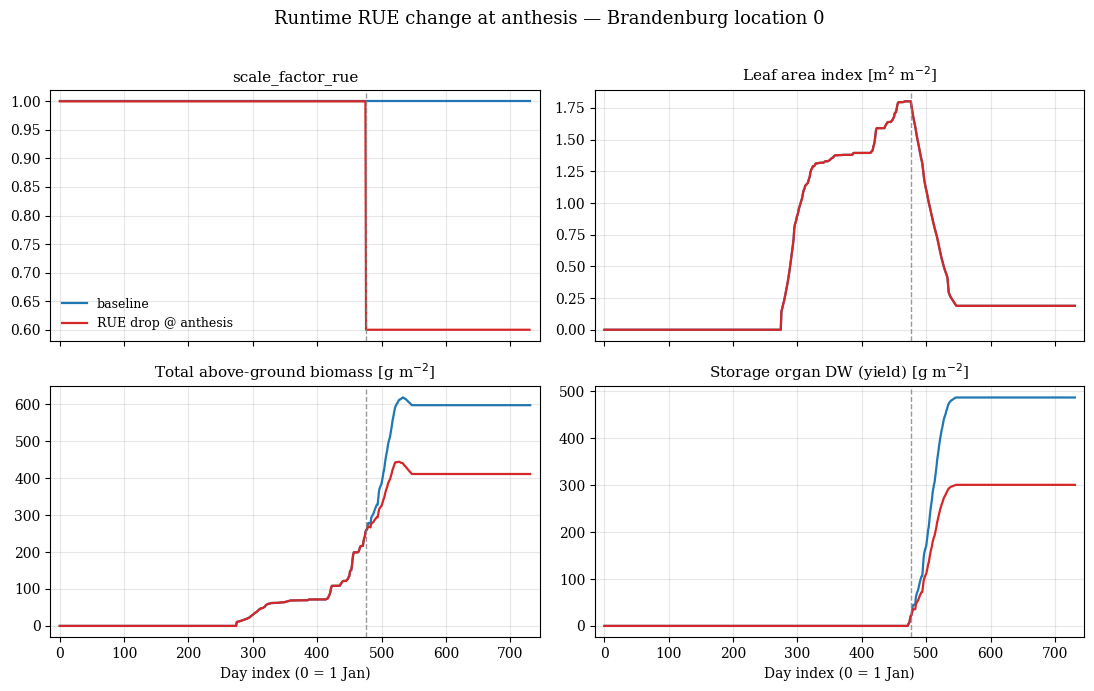

In [7]:
# Day the perturbation kicked in (first day the perturbed scale != 1.0).
changed = np.where(perturbed["rue_scale"] != 1.0)[0]
change_day = int(changed[0]) if len(changed) else None

days_state = np.arange(len(baseline["lai"]))     # T + 1
days_rate = np.arange(len(baseline["rue_scale"]))  # T

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
panels = [
    ("rue_scale", days_rate, "scale_factor_rue", "-"),
    ("lai", days_state, "Leaf area index [m$^2$ m$^{-2}$]", "m$^2$ m$^{-2}$"),
    ("biomass", days_state, "Total above-ground biomass [g m$^{-2}$]", ""),
    ("wso", days_state, "Storage organ DW (yield) [g m$^{-2}$]", ""),
]
for ax, (key, x, title, _unit) in zip(axes.ravel(), panels):
    ax.plot(x, baseline[key], color="#1f77b4", lw=1.6, label="baseline")
    ax.plot(x, perturbed[key], color="#d62728", lw=1.6, ls="-", label="RUE drop @ anthesis")
    if change_day is not None:
        ax.axvline(change_day, color="grey", ls="--", lw=1.0, alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)
    ax.margins(x=0.02)

for ax in axes[-1]:
    ax.set_xlabel("Day index (0 = 1 Jan)")
axes[0, 0].legend(fontsize=9, frameon=False)
fig.suptitle(f"Runtime RUE change at anthesis — Brandenburg location {LOCATION}",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Part 2 — State edits: LAI and soil moisture

`LAI` and root-zone soil water `wa` are **state** variables — they live on the
`ModelState`, not on the parameter dataclasses — so we edit them differently.
Inside `on_step` we return a _new_ state built with
[`dataclasses.replace`](https://docs.python.org/3/library/dataclasses.html#dataclasses.replace),
which copies the dataclass with the named fields swapped out. This respects the
project's **no-in-place-writes** rule (we never do `state.lai[...] = ...`), so the
same hook works unchanged inside an autograd-tracked run.

**Why a different production mode here.** In Part 1's potential mode the water
balance refills the root zone to field capacity every day and `TRANRF` is pinned
at `1`, so a one-off edit to `wa` would simply wash out and never affect growth.
To make the soil-moisture edit _meaningful_ we switch to **water-limited,
rain-fed** mode (`iopt = 2`, `irri = 0`): now `wa` is a genuine prognostic store,
and water stress `TRANRF = f(wa)` throttles assimilation. `LAI` already matters in
either mode (it sets light interception), but we keep both edits in the same
water-limited run for a single, consistent comparison.


In [8]:
# A fresh model for this location in water-limited, rain-fed mode.
weather_wl, soil_wl, site_wl = load_location(LOCATION)

crop_wl = CropParameters(crop_name="wheat")
crop_wl.iopt = torch.tensor(2.0)     # water-limited: water stress active
soil_wl.irri = torch.tensor(0.0)     # rain-fed: no automatic refill

crop_wl = crop_wl.to(device=device)
soil_wl = soil_wl.to(device=device)
site_wl = site_wl.to(device=device)
weather_wl = weather_wl.to(device=device)

model_wl = Lintul5Model(crop_wl, soil_wl, site_wl).eval().to(device)

# Reference run with no edits.
baseline_wl = run_stepwise(model_wl, weather_wl, start_doy=1)
print(f"Water-limited baseline yield: {baseline_wl['wso'][-1]:.1f} g m-2")

# Pick a data-driven event day: the first day the canopy is established
# (DVS >= 0.5), so both edits land during active growth.
event_day = int(np.argmax(baseline_wl["dvs"][:-1] >= 0.5))
print(f"Event day index: {event_day} (DVS={baseline_wl['dvs'][event_day]:.2f})")

Water-limited baseline yield: 456.2 g m-2
Event day index: 332 (DVS=0.50)


### Two state-edit hooks

- **Defoliation** — on a single day, halve the leaf area: replace `lai` with
  `lai * keep`. (A fuller "hail/grazing" model would scale green-leaf mass `wlv`
  too; we keep it to `lai` to isolate the light-interception pathway.)
- **Drought** — impose a dry spell: for every day in a window, knock the root-zone
  water down to a fraction of its current value (`wa * keep`). Because the water
  balance is now prognostic, this drags `TRANRF` down and suppresses growth until
  rains refill the profile.

Both are pure `dataclasses.replace` edits returned from `on_step`; neither touches
`model_wl`'s parameters, so the three runs below share one model with no resets.


In [9]:
def make_defoliation(day, keep=0.5):
    """`on_step` hook: halve LAI on a single `day`."""
    def on_step(t, state, model):
        if t == day:
            print(f"  day {t}: defoliation, LAI {float(state.lai[0]):.2f} -> "
                  f"{float(state.lai[0]) * keep:.2f}")
            return dataclasses.replace(state, lai=state.lai * keep)
        return None
    return on_step


def make_drought(day, duration=30, keep=0.3):
    """`on_step` hook: hold root-zone water at a fraction over a dry-spell window."""
    def on_step(t, state, model):
        if day <= t < day + duration:
            return dataclasses.replace(state, wa=state.wa * keep)
        return None
    return on_step


defoliation = run_stepwise(model_wl, weather_wl, start_doy=1,
                           on_step=make_defoliation(event_day, keep=0.5))
drought = run_stepwise(model_wl, weather_wl, start_doy=1,
                       on_step=make_drought(event_day, duration=30, keep=0.3))

for name, run in [("defoliation (LAI x0.5)", defoliation),
                  ("drought (wa x0.3, 30 d)", drought)]:
    dy = 100.0 * (1.0 - run['wso'][-1] / baseline_wl['wso'][-1])
    print(f"{name:26s}: yield {run['wso'][-1]:6.1f} g m-2  ({-dy:+.1f}%)")

  day 332: defoliation, LAI 1.32 -> 0.66
defoliation (LAI x0.5)    : yield  293.1 g m-2  (-35.8%)
drought (wa x0.3, 30 d)   : yield   46.1 g m-2  (-89.9%)


### Visualise the state edits

The same four-panel layout, now with three lines (baseline, defoliation,
drought). The grey band marks the 30-day drought window; the dashed line marks
the single defoliation day.

1. **LAI** — drops sharply on the defoliation day, then keeps developing from the
   lowered level.
2. **Root-zone water `wa`** — held down through the drought window, then recovers.
3. **Water stress `TRANRF`** — falls during the dry spell (`1` = unstressed);
   flat at the top for the others.
4. **Storage-organ weight `WSO`** — the resulting yield gap for each scenario.


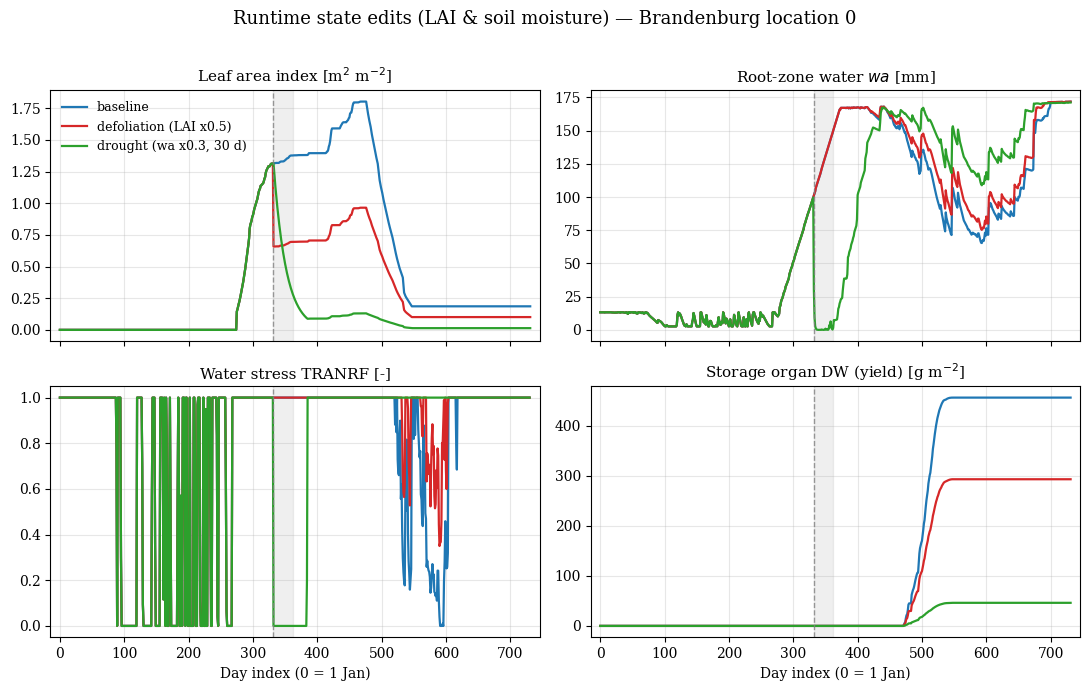

In [10]:
days_state = np.arange(len(baseline_wl["lai"]))     # T + 1
days_rate = np.arange(len(baseline_wl["tranrf"]))   # T

runs = [
    ("baseline", baseline_wl, "#1f77b4"),
    ("defoliation (LAI x0.5)", defoliation, "#d62728"),
    ("drought (wa x0.3, 30 d)", drought, "#2ca02c"),
]
panels = [
    ("lai", days_state, "Leaf area index [m$^2$ m$^{-2}$]"),
    ("wa", days_state, "Root-zone water $wa$ [mm]"),
    ("tranrf", days_rate, "Water stress TRANRF [-]"),
    ("wso", days_state, "Storage organ DW (yield) [g m$^{-2}$]"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, (key, x, title) in zip(axes.ravel(), panels):
    for label, run, color in runs:
        ax.plot(x, run[key], color=color, lw=1.6, label=label)
    ax.axvspan(event_day, event_day + 30, color="grey", alpha=0.12)
    ax.axvline(event_day, color="grey", ls="--", lw=1.0, alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)
    ax.margins(x=0.02)

for ax in axes[-1]:
    ax.set_xlabel("Day index (0 = 1 Jan)")
axes[0, 0].legend(fontsize=9, frameon=False)
fig.suptitle(
    f"Runtime state edits (LAI & soil moisture) — Brandenburg location {LOCATION}",
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Takeaways

- The step-wise API (`initialize` → `compute_rates` → `update_state`) exposes the
  state **between** every Euler day, which is exactly where runtime edits belong.
- **Parameter edits**: mutate `model.crop_params.<name>` (or `soil_params` /
  `site_params`) in place — it takes effect on the **next** `compute_rates` call,
  because the process modules read those tensors fresh each step.
- **State edits**: return a new `ModelState` from the hook via
  `dataclasses.replace(state, lai=..., wa=...)`. No in-place writes, so the same
  edit is safe inside an autograd-tracked run.
- Edits can be **state-driven** (keyed on live `DVS` here) rather than tied to a
  calendar day, so the same logic adapts across locations and years.
- Match the **production mode** to the edit: a soil-water edit only persists in
  water-limited / rain-fed mode (`iopt = 2`, `irri = 0`); in potential mode the
  water balance refills it and `TRANRF` stays at `1`.
- For optimisation, drop `torch.no_grad()` and make the edited value an
  `nn.Parameter`: gradients then flow through the full day-by-day chain. For
  pre-planned daily inputs you don't need this loop at all — pass
  `irrigation [B, T]` / `fertilizer [B, T, 3]` straight to `model(...)`.
